## 智能体三大经典范式
* ReAct (Reasoning and Acting)： 一种将“思考”和“行动”紧密结合的范式，让智能体边想边做，动态调整。
* Plan-and-Solve： 一种“三思而后行”的范式，智能体首先生成一个完整的行动计划，然后严格执行。
* Reflection： 一种赋予智能体“反思”能力的范式，通过自我批判和修正来优化结果

In [ ]:
import os
from openai import OpenAI
from dotenv import load_dotenv
from typing import List, Dict

# 加载 .env 文件中的环境变量
load_dotenv()

class HelloAgentsLLM:
    """
    为本书 "Hello Agents" 定制的LLM客户端。
    它用于调用任何兼容OpenAI接口的服务，并默认使用流式响应。
    """
    def __init__(self, model: str = None, apiKey: str = None, baseUrl: str = None, timeout: int = None):
        """
        初始化客户端。优先使用传入参数，如果未提供，则从环境变量加载。
        """
        self.model = model or os.getenv("DEEPSEEK_MODEL_ID")
        apiKey = apiKey or os.getenv("DEEPSEEK_API_KEY")
        baseUrl = baseUrl or os.getenv("DEEPSEEK_BASE_URL")
        timeout = timeout or int(os.getenv("LLM_TIMEOUT", 60))
        
        if not all([self.model, apiKey, baseUrl]):
            raise ValueError("模型ID、API密钥和服务地址必须被提供或在.env文件中定义。")

        self.client = OpenAI(api_key=apiKey, base_url=baseUrl, timeout=timeout)

    def think(self, messages: List[Dict[str, str]], temperature: float = 0) -> str:
        """
        调用大语言模型进行思考，并返回其响应。
        """
        print(f"🧠 正在调用 {self.model} 模型...")
        try:
            response = self.client.chat.completions.create(
                model=self.model,
                messages=messages,
                temperature=temperature,
                stream=True,
            )
            
            # 处理流式响应
            print("✅ 大语言模型响应成功:")
            collected_content = []
            """
            for chunk in responsestream=True 时，response 是一个迭代器，会持续接收模型生成的文字块，直到结束。
            chunk.choices[0].delta.content这是流式响应的固定数据格式：
            choices[0]：取第一个回答（大模型默认只返回一个回答）
            delta：增量内容（每个 chunk 只返回新生成的几个字，不是全部）
            content：实际文字
            or ""模型结束时，delta.content 会是 None，直接用会报错，所以强制转为空字符串。
            print(content, end="", flush=True)
            end=""：不自动换行，实现逐字输出效果
            flush=True：强制刷新打印缓冲区（不加这一句，不会实时显示文字）
            列表收集 + 拼接用列表 collected_content 收集所有片段，最后用 join 拼接（比字符串拼接效率高）。
            """
            for chunk in response:
                content = chunk.choices[0].delta.content or ""
                print(content, end="", flush=True)
                collected_content.append(content)
            print()  # 在流式输出结束后换行
            return "".join(collected_content)

        except Exception as e:
            print(f"❌ 调用LLM API时发生错误: {e}")
            return None

# --- 客户端使用示例 ---
if __name__ == '__main__':
    try:
        llmClient = HelloAgentsLLM()
        
        exampleMessages = [
            {"role": "system", "content": "You are a helpful assistant that writes Python code."},
            {"role": "user", "content": "写一个快速排序算法"}
        ]
        
        print("--- 调用LLM ---")
        responseText = llmClient.think(exampleMessages)
        if responseText:
            print("\n\n--- 完整模型响应 ---")
            print(responseText)

    except ValueError as e:
        print(e)

### ReAct
将推理 (Reasoning) 与行动 (Acting) 显式地结合起来，形成一个“思考-行动-观察”的循环

***ReAct流程***

ReAct的巧妙之处在于，它认识到思考与行动是相辅相成的。思考指导行动，而行动的结果又反过来修正思考。为此，ReAct范式通过一种特殊的提示工程来引导模型，使其每一步的输出都遵循一个固定的轨迹：

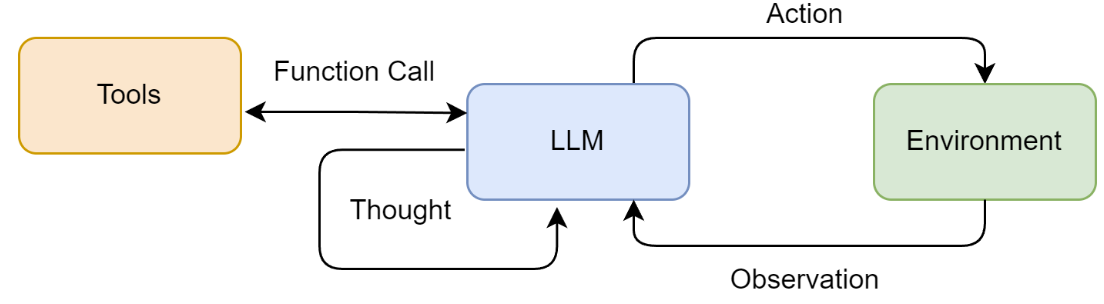


>Thought (思考)： 这是智能体的“内心独白”。它会分析当前情况、分解任务、制定下一步计划，或者反思上一步的结果。

>Action (行动)： 这是智能体决定采取的具体动作，通常是调用一个外部工具，例如 Search['华为最新款手机']。

>Observation (观察)： 这是执行Action后从外部工具返回的结果，例如搜索结果的摘要或API的返回值。

***这种机制特别适用于以下场景：***

>需要外部知识的任务：如查询实时信息（天气、新闻、股价）、搜索专业领域的知识等。

>需要精确计算的任务：将数学问题交给计算器工具，避免LLM的计算错误。

>需要与API交互的任务：如操作数据库、调用某个服务的API来完成特定功能。

In [ ]:
from serpapi import SerpApiClient

def search(query: str) -> str:
    """
    一个基于SerpApi的实战网页搜索引擎工具。
    它会智能地解析搜索结果，优先返回直接答案或知识图谱信息。
    """
    print(f"🔍 正在执行 [SerpApi] 网页搜索: {query}")
    try:
        api_key = os.getenv("SERPAPI_API_KEY")
        if not api_key:
            return "错误:SERPAPI_API_KEY 未在 .env 文件中配置。"

        params = {
            "engine": "google",
            "q": query,
            "api_key": api_key,
            "gl": "cn",  # 国家代码
            "hl": "zh-cn", # 语言代码
        }
        
        client = SerpApiClient(params)
        results = client.get_dict()
        
        # 智能解析:优先寻找最直接的答案
        if "answer_box_list" in results:
            return "\n".join(results["answer_box_list"])
        if "answer_box" in results and "answer" in results["answer_box"]:
            return results["answer_box"]["answer"]
        if "knowledge_graph" in results and "description" in results["knowledge_graph"]:
            return results["knowledge_graph"]["description"]
        if "organic_results" in results and results["organic_results"]:
            # 如果没有直接答案，则返回前三个有机结果的摘要
            snippets = [
                f"[{i+1}] {res.get('title', '')}\n{res.get('snippet', '')}"
                for i, res in enumerate(results["organic_results"][:3])
            ]
            return "\n\n".join(snippets)
        
        return f"对不起，没有找到关于 '{query}' 的信息。"

    except Exception as e:
        return f"搜索时发生错误: {e}"


***实现搜索工具的核心逻辑***

一个良好定义的工具应包含以下三个核心要素：

>名称 (Name)： 一个简洁、唯一的标识符，供智能体在 Action 中调用，例如 Search。

>描述 (Description)： 一段清晰的自然语言描述，说明这个工具的用途。这是整个机制中最关键的部分，因为大语言模型会依赖这段描述来判断何时使用哪个工具。

>执行逻辑 (Execution Logic)： 真正执行任务的函数或方法。

In [ ]:
from typing import Dict, Any

class ToolExecutor:
    """
    一个统一的管理器来注册和调度智能体所需的工具
    """
    def __init__(self):
        self.tools: Dict[str, Dict[str, Any]] = {}

    def registerTool(self, name: str, description: str, func: callable):
        """
        向工具箱中注册一个新工具。
        """
        if name in self.tools:
            print(f"警告:工具 '{name}' 已存在，将被覆盖。")
        self.tools[name] = {"description": description, "func": func}
        print(f"工具 '{name}' 已注册。")

    def getTool(self, name: str) -> callable:
        """
        根据名称获取一个工具的执行函数。
        """
        return self.tools.get(name, {}).get("func")

    def getAvailableTools(self) -> str:
        """
        获取所有可用工具的格式化描述字符串。
        """
        return "\n".join([
            f"- {name}: {info['description']}" 
            for name, info in self.tools.items()
        ])

In [ ]:
# --- 工具初始化与使用示例 ---
if __name__ == '__main__':
    # 1. 初始化工具执行器
    toolExecutor = ToolExecutor()

    # 2. 注册我们的实战搜索工具
    search_description = "一个网页搜索引擎。当你需要回答关于时事、事实以及在你的知识库中找不到的信息时，应使用此工具。"
    toolExecutor.registerTool("Search", search_description, search)
    
    # 3. 打印可用的工具
    print("\n--- 可用的工具 ---")
    print(toolExecutor.getAvailableTools())

    # 4. 智能体的Action调用，这次我们问一个实时性的问题
    print("\n--- 执行 Action: Search['英伟达最新的GPU型号是什么'] ---")
    tool_name = "Search"
    tool_input = "英伟达最新的GPU型号是什么"

    tool_function = toolExecutor.getTool(tool_name)
    if tool_function:
        observation = tool_function(tool_input)
        print("--- 观察 (Observation) ---")
        print(observation)
    else:
        print(f"错误:未找到名为 '{tool_name}' 的工具。")

In [ ]:
# ReAct 提示词模板
REACT_PROMPT_TEMPLATE = """
请注意，你是一个有能力调用外部工具的智能助手。

可用工具如下:
{tools}

请严格按照以下格式进行回应:

Thought: 你的思考过程，用于分析问题、拆解任务和规划下一步行动。
Action: 你决定采取的行动，必须是以下格式之一:
- `{{tool_name}}[{{tool_input}}]`:调用一个可用工具。
- `Finish[最终答案]`:当你认为已经获得最终答案时。
- 当你收集到足够的信息，能够回答用户的最终问题时，你必须在Action:字段后使用 Finish[最终答案] 来输出最终答案。

现在，请开始解决以下问题:
Question: {question}
History: {history}
"""


提示词是整个 ReAct 机制的基石，它为大语言模型提供了行动的操作指令。我们需要精心设计一个模板，它将动态地插入可用工具、用户问题以及中间步骤的交互历史。

***这个模板定义了智能体与LLM之间交互的规范：***

>角色定义： “你是一个有能力调用外部工具的智能助手”，设定了LLM的角色。

>工具清单 ({tools})： 告知LLM它有哪些可用的“手脚”。

>格式规约 (Thought/Action)： 这是最重要的部分，它强制LLM的输出具有结构性，使我们能通过代码精确解析其意图。

>动态上下文 ({question}/{history})： 将用户的原始问题和不断累积的交互历史注入，让LLM基于完整的上下文进行决策。

In [ ]:
class ReActAgent:
    """
    ReActAgent 的核心是一个循环，它不断地“格式化提示词 -> 调用LLM -> 执行动作 -> 整合结果”，直到任务完成或达到最大步数限制。
    """
    def __init__(self, llm_client: HelloAgentsLLM, tool_executor: ToolExecutor, max_steps: int = 5):
        self.llm_client = llm_client
        self.tool_executor = tool_executor
        self.max_steps = max_steps
        self.history = []

    def run(self, question: str):
        """
        运行ReAct智能体来回答一个问题。
        """
        self.history = [] # 每次运行时重置历史记录
        current_step = 0

        while current_step < self.max_steps:
            current_step += 1
            print(f"--- 第 {current_step} 步 ---")

            # 1. 格式化提示词
            tools_desc = self.tool_executor.getAvailableTools()
            history_str = "\n".join(self.history)
            prompt = REACT_PROMPT_TEMPLATE.format(
                tools=tools_desc,
                question=question,
                history=history_str
            )

            # 2. 调用LLM进行思考
            messages = [{"role": "user", "content": prompt}]
            response_text = self.llm_client.think(messages=messages)
            
            if not response_text:
                print("错误:LLM未能返回有效响应。")
                break

            # 3. 解析LLM的输出
            # 用到了类里面的两个解析方法
            thought, action = self._parse_output(response_text)
            
            if thought:
                print(f"思考: {thought}")

            if not action:
                print("警告:未能解析出有效的Action，流程终止。")
                break

            # 4. 执行Action
            # 首先检查是否为Finish指令，如果是，则流程结束。否则，它会通过tool_executor获取对应的工具函数并执行，得到observation。
            if action.startswith("Finish"):
                # 如果是Finish指令，提取最终答案并结束
                final_answer = re.match(r"Finish\[(.*)\]", action).group(1)
                print(f"🎉 最终答案: {final_answer}")
                return final_answer
            
            tool_name, tool_input = self._parse_action(action)
            if not tool_name or not tool_input:
                # ... 处理无效Action格式 ...
                continue

            print(f"🎬 行动: {tool_name}[{tool_input}]")
            
            tool_function = self.tool_executor.getTool(tool_name)
            if not tool_function:
                observation = f"错误:未找到名为 '{tool_name}' 的工具。"
            else:
                observation = tool_function(tool_input) # 调用真实工具
    
            
            # 将Action本身和工具执行后的Observation添加回历史记录中，为下一轮循环提供新的上下文
            print(f"👀 观察: {observation}")
            
            # 将本轮的Action和Observation添加到历史记录中
            self.history.append(f"Action: {action}")
            self.history.append(f"Observation: {observation}")

        # 循环结束
        print("已达到最大步数，流程终止。")
        return None

    

    def _parse_output(self, text: str):
        """解析LLM的输出，提取Thought和Action。
        """
        # Thought: 匹配到 Action: 或文本末尾
        thought_match = re.search(r"Thought:\s*(.*?)(?=\nAction:|$)", text, re.DOTALL)
        # Action: 匹配到文本末尾
        action_match = re.search(r"Action:\s*(.*?)$", text, re.DOTALL)
        thought = thought_match.group(1).strip() if thought_match else None
        action = action_match.group(1).strip() if action_match else None
        return thought, action

    def _parse_action(self, action_text: str):
        """解析Action字符串，提取工具名称和输入。例如从 Search[华为最新手机] 中提取出工具名 Search 和工具输入 华为最新手机。
        """
        match = re.match(r"(\w+)\[(.*)\]", action_text, re.DOTALL)
        if match:
            return match.group(1), match.group(2)
        return None, None

***ReAct 的主要特点***

>高可解释性：ReAct 最大的优点之一就是透明。通过 Thought 链，我们可以清晰地看到智能体每一步的“心路历程”——它为什么会选择这个工具，下一步又打算做什么。这对于理解、信任和调试智能体的行为至关重要。

>动态规划与纠错能力：与一次性生成完整计划的范式不同，ReAct 是“走一步，看一步”。它根据每一步从外部世界获得的 Observation 来动态调整后续的 Thought 和 Action。如果上一步的搜索结果不理想，它可以在下一步中修正搜索词，重新尝试。

>工具协同能力：ReAct 范式天然地将大语言模型的推理能力与外部工具的执行能力结合起来。LLM 负责运筹帷幄（规划和推理），工具负责解决具体问题（搜索、计算），二者协同工作，突破了单一 LLM 在知识时效性、计算准确性等方面的固有局限。

***ReAct 的固有局限性***

>对LLM自身能力的强依赖：ReAct 流程的成功与否，高度依赖于底层 LLM 的综合能力。如果 LLM 的逻辑推理能力、指令遵循能力或格式化输出能力不足，就很容易在 Thought 环节产生错误的规划，或者在 Action 环节生成不符合格式的指令，导致整个流程中断。

>执行效率问题：由于其循序渐进的特性，完成一个任务通常需要多次调用 LLM。每一次调用都伴随着网络延迟和计算成本。对于需要很多步骤的复杂任务，这种串行的“思考-行动”循环可能会导致较高的总耗时和费用。

>提示词的脆弱性：整个机制的稳定运行建立在一个精心设计的提示词模板之上。模板中的任何微小变动，甚至是用词的差异，都可能影响 LLM 的行为。此外，并非所有模型都能持续稳定地遵循预设的格式，这增加了在实际应用中的不确定性。

>可能陷入局部最优：步进式的决策模式意味着智能体缺乏一个全局的、长远的规划。它可能会因为眼前的 Observation 而选择一个看似正确但长远来看并非最优的路径，甚至在某些情况下陷入“原地打转”的循环中。

***调试技巧***

>检查完整的提示词：在每次调用 LLM 之前，将最终格式化好的、包含所有历史记录的完整提示词打印出来。这是追溯 LLM 决策源头的最直接方式。

>分析原始输出：当输出解析失败时（例如，正则表达式没有匹配到 Action），务必将 LLM 返回的原始、未经处理的文本打印出来。这能帮助你判断是 LLM 没有遵循格式，还是你的解析逻辑有误。

>验证工具的输入与输出：检查智能体生成的 tool_input 是否是工具函数所期望的格式，同时也要确保工具返回的 observation 格式是智能体可以理解和处理的。
调整提示词中的示例 (Few-shot Prompting)：如果模型频繁出错，可以在提示词中加入一两个完整的“Thought-Action-Observation”成功案例，通过示例来引导模型更好地遵循你的指令。

>尝试不同的模型或参数：更换一个能力更强的模型，或者调整 temperature 参数（通常设为0以保证输出的确定性），有时能直接解决问题。

## Plan-and-Solve
这种范式将任务处理明确地分为两个阶段：先规划 (Plan)，后执行 (Solve)。

>规划阶段 (Planning Phase)： 首先，智能体会接收用户的完整问题。它的第一个任务不是直接去解决问题或调用工具，而是将问题分解，并制定出一个清晰、分步骤的行动计划。这个计划本身就是一次大语言模型的调用产物。

>执行阶段 (Solving Phase)： 在获得完整的计划后，智能体进入执行阶段。它会严格按照计划中的步骤，逐一执行。每一步的执行都可能是一次独立的 LLM 调用，或者是对上一步结果的加工处理，直到计划中的所有步骤都完成，最终得出答案。

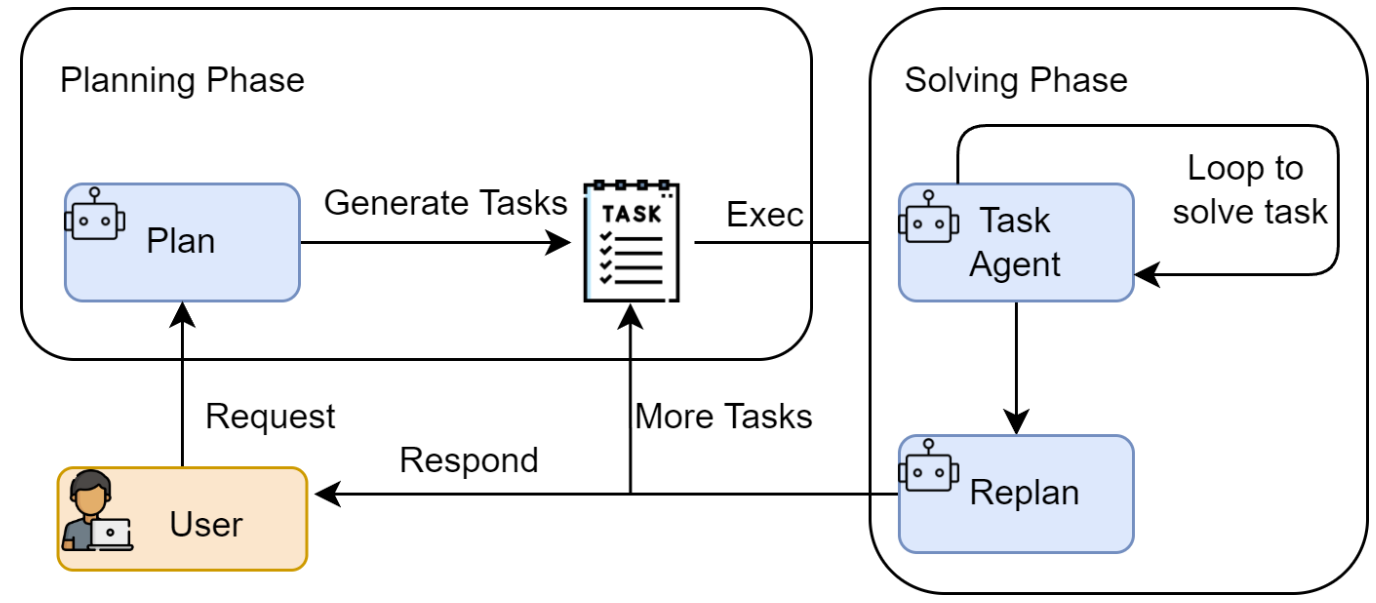


Plan-and-Solve 尤其适用于那些结构性强、可以被清晰分解的复杂任务，例如：

>多步数学应用题：需要先列出计算步骤，再逐一求解。

>需要整合多个信息源的报告撰写：需要先规划好报告结构（引言、数据来源A、数据来源B、总结），再逐一填充内容。

>代码生成任务：需要先构思好函数、类和模块的结构，再逐一实现。

In [ ]:
PLANNER_PROMPT_TEMPLATE = """
你是一个顶级的AI规划专家。你的任务是将用户提出的复杂问题分解成一个由多个简单步骤组成的行动计划。
请确保计划中的每个步骤都是一个独立的、可执行的子任务，并且严格按照逻辑顺序排列。
你的输出必须是一个Python列表，其中每个元素都是一个描述子任务的字符串。

问题: {question}

请严格按照以下格式输出你的计划,```python与```作为前后缀是必要的:
```python
["步骤1", "步骤2", "步骤3", ...]
```
"""

In [ ]:
# 假定 llm_client.py 中的 HelloAgentsLLM 类已经定义好
# from llm_client import HelloAgentsLLM

class Planner:
    def __init__(self, llm_client):
        self.llm_client = llm_client

    def plan(self, question: str) -> list[str]:
        """
        根据用户问题生成一个行动计划。
        """
        prompt = PLANNER_PROMPT_TEMPLATE.format(question=question)
        
        # 为了生成计划，我们构建一个简单的消息列表
        messages = [{"role": "user", "content": prompt}]
        
        print("--- 正在生成计划 ---")
        # 使用流式输出来获取完整的计划
        response_text = self.llm_client.think(messages=messages) or ""
        
        print(f"✅ 计划已生成:\n{response_text}")
        
        # 解析LLM输出的列表字符串
        try:
            # 找到```python和```之间的内容
            plan_str = response_text.split("```python")[1].split("```")[0].strip()
            # 使用ast.literal_eval来安全地执行字符串，将其转换为Python列表
            plan = ast.literal_eval(plan_str)
            return plan if isinstance(plan, list) else []
        except (ValueError, SyntaxError, IndexError) as e:
            print(f"❌ 解析计划时出错: {e}")
            print(f"原始响应: {response_text}")
            return []
        except Exception as e:
            print(f"❌ 解析计划时发生未知错误: {e}")
            return []


### 规划阶段
通过提示词让agent分解问题，输出详细计划

In [ ]:
EXECUTOR_PROMPT_TEMPLATE = """
你是一位顶级的AI执行专家。你的任务是严格按照给定的计划，一步步地解决问题。
你将收到原始问题、完整的计划、以及到目前为止已经完成的步骤和结果。
请你专注于解决“当前步骤”，并仅输出该步骤的最终答案，不要输出任何额外的解释或对话。

# 原始问题:
{question}

# 完整计划:
{plan}

# 历史步骤与结果:
{history}

# 当前步骤:
{current_step}

请仅输出针对“当前步骤”的回答:
"""


In [ ]:
class Executor:
    def __init__(self, llm_client):
        self.llm_client = llm_client

    def execute(self, question: str, plan: list[str]) -> str:
        """
        根据计划，逐步执行并解决问题。
        """
        history = "" # 用于存储历史步骤和结果的字符串
        
        print("\n--- 正在执行计划 ---")
        
        for i, step in enumerate(plan):
            print(f"\n-> 正在执行步骤 {i+1}/{len(plan)}: {step}")
            
            prompt = EXECUTOR_PROMPT_TEMPLATE.format(
                question=question,
                plan=plan,
                history=history if history else "无", # 如果是第一步，则历史为空
                current_step=step
            )
            
            messages = [{"role": "user", "content": prompt}]
            
            response_text = self.llm_client.think(messages=messages) or ""
            
            # 更新历史记录，为下一步做准备
            history += f"步骤 {i+1}: {step}\n结果: {response_text}\n\n"
            
            print(f"✅ 步骤 {i+1} 已完成，结果: {response_text}")

        # 循环结束后，最后一步的响应就是最终答案
        final_answer = response_text
        return final_answer


### 执行阶段
执行器的提示词与规划器不同。它的目标不是分解问题，而是在已有上下文的基础上，专注解决当前这一个步骤。因此，提示词需要包含以下关键信息：

>原始问题： 确保模型始终了解最终目标。

>完整计划： 让模型了解当前步骤在整个任务中的位置。

>历史步骤与结果： 提供至今为止已经完成的工作，作为当前步骤的直接输入。

>当前步骤： 明确指示模型现在需要解决哪一个具体任务。

In [ ]:
class PlanAndSolveAgent:
    def __init__(self, llm_client):
        """
        初始化智能体，同时创建规划器和执行器实例。
        """
        self.llm_client = llm_client
        self.planner = Planner(self.llm_client)
        self.executor = Executor(self.llm_client)

    def run(self, question: str):
        """
        运行智能体的完整流程:先规划，后执行。
        """
        print(f"\n--- 开始处理问题 ---\n问题: {question}")
        
        # 1. 调用规划器生成计划
        plan = self.planner.plan(question)
        
        # 检查计划是否成功生成
        if not plan:
            print("\n--- 任务终止 --- \n无法生成有效的行动计划。")
            return

        # 2. 调用执行器执行计划
        final_answer = self.executor.execute(question, plan)
        
        print(f"\n--- 任务完成 ---\n最终答案: {final_answer}")


## Reflection
Reflection 机制的灵感来源于人类的学习过程：我们完成初稿后会进行校对，解出数学题后会进行验算。其核心工作流程可以概括为一个简洁的三步循环：执行 -> 反思 -> 优化。

* 执行 (Execution)：首先，智能体使用我们熟悉的方法（如 ReAct 或 Plan-and-Solve）尝试完成任务，生成一个初步的解决方案或行动轨迹。这可以看作是“初稿”。

* 反思 (Reflection)：接着，智能体进入反思阶段。它会调用一个独立的、或者带有特殊提示词的大语言模型实例，来扮演一个“评审员”的角色。这个“评审员”会审视第一步生成的“初稿”，并从多个维度进行评估，例如：

>事实性错误：是否存在与常识或已知事实相悖的内容？

>逻辑漏洞：推理过程是否存在不连贯或矛盾之处？

>效率问题：是否有更直接、更简洁的路径来完成任务？

>遗漏信息：是否忽略了问题的某些关键约束或方面？ 根据评估，它会生成一段结构化的反馈 (Feedback)，指出具体的问题所在和改进建议。

* 优化 (Refinement)：最后，智能体将“初稿”和“反馈”作为新的上下文，再次调用大语言模型，要求它根据反馈内容对初稿进行修正，生成一个更完善的“修订稿”。

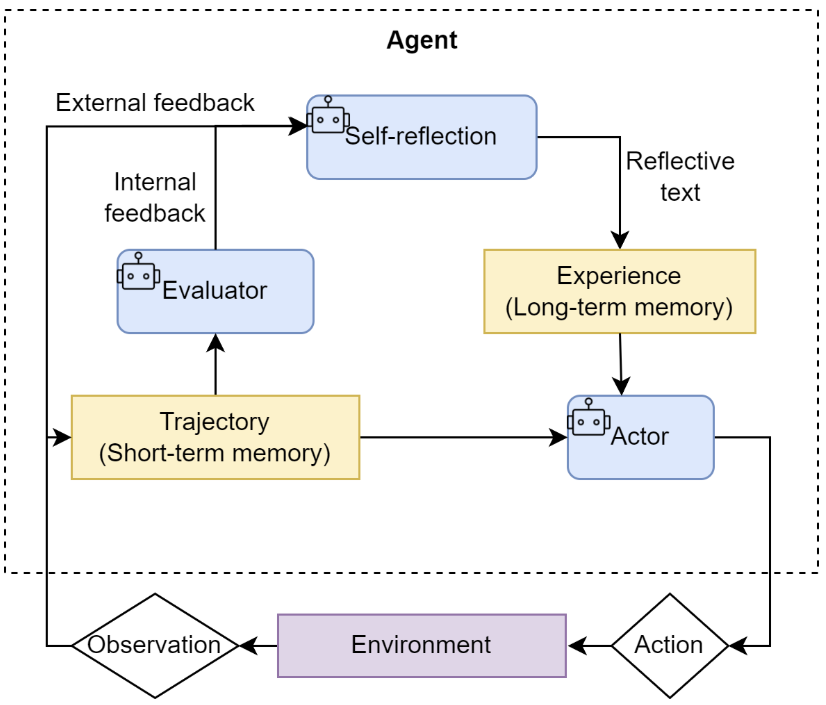

与前两种范式相比，Reflection 的价值在于：

>它为智能体提供了一个内部纠错回路，使其不再完全依赖于外部工具的反馈（ReAct 的 Observation），从而能够修正更高层次的逻辑和策略错误。

>它将一次性的任务执行，转变为一个持续优化的过程，显著提升了复杂任务的最终成功率和答案质量。

>它为智能体构建了一个临时的“短期记忆”。整个“执行-反思-优化”的轨迹形成了一个宝贵的经验记录，智能体不仅知道最终答案，还记得自己是如何从有缺陷的初稿迭代到最终版本的。更进一步，这个记忆系统还可以是
多模态的，允许智能体反思和修正文本以外的输出（如代码、图像等），为构建更强大的多模态智能体奠定了基础。

In [ ]:
from typing import List, Dict, Any, Optional

class Memory:
    """
    一个简单的短期记忆模块，用于存储智能体的行动与反思轨迹。
    使用一个列表 records 来按顺序存储每一次的行动和反思。
    add_record 方法负责向记忆中添加新的条目。
    get_trajectory 方法是核心，它将记忆轨迹“序列化”成一段文本，可以直接插入到后续的提示词中，为模型的反思和优化提供完整的上下文。
    get_last_execution 方便我们获取最新的“初稿”以供反思。
    """

    def __init__(self):
        """
        初始化一个空列表来存储所有记录。
        """
        self.records: List[Dict[str, Any]] = []

    def add_record(self, record_type: str, content: str):
        """
        向记忆中添加一条新记录。

        参数:
        - record_type (str): 记录的类型 ('execution' 或 'reflection')。
        - content (str): 记录的具体内容 (例如，生成的代码或反思的反馈)。
        """
        record = {"type": record_type, "content": content}
        self.records.append(record)
        print(f"📝 记忆已更新，新增一条 '{record_type}' 记录。")

    def get_trajectory(self) -> str:
        """
        将所有记忆记录格式化为一个连贯的字符串文本，用于构建提示词。
        """
        trajectory_parts = []
        for record in self.records:
            if record['type'] == 'execution':
                trajectory_parts.append(f"--- 上一轮尝试 (代码) ---\n{record['content']}")
            elif record['type'] == 'reflection':
                trajectory_parts.append(f"--- 评审员反馈 ---\n{record['content']}")
        
        return "\n\n".join(trajectory_parts)

    def get_last_execution(self) -> Optional[str]:
        """
        获取最近一次的执行结果 (例如，最新生成的代码)。
        如果不存在，则返回 None。
        """
        for record in reversed(self.records):
            if record['type'] == 'execution':
                return record['content']
        return None


Reflection 的核心在于迭代，而迭代的前提是能够记住之前的尝试和获得的反馈。因此，一个“短期记忆”模块是实现该范式的必需品。这个记忆模块将负责存储每一次“执行-反思”循环的完整轨迹。

In [ ]:
INITIAL_PROMPT_TEMPLATE = """
你是一位资深的Python程序员。请根据以下要求，编写一个Python函数。
你的代码必须包含完整的函数签名、文档字符串，并遵循PEP 8编码规范。

要求: {task}

请直接输出代码，不要包含任何额外的解释。
"""


初始执行提示词 (Execution Prompt) ：这是智能体首次尝试解决问题的提示词，内容相对直接，只要求模型完成指定任务。

In [ ]:
REFLECT_PROMPT_TEMPLATE = """
你是一位极其严格的代码评审专家和资深算法工程师，对代码的性能有极致的要求。
你的任务是审查以下Python代码，并专注于找出其在<strong>算法效率</strong>上的主要瓶颈。

# 原始任务:
{task}

# 待审查的代码:
```python
{code}
```

请分析该代码的时间复杂度，并思考是否存在一种<strong>算法上更优</strong>的解决方案来显著提升性能。
如果存在，请清晰地指出当前算法的不足，并提出具体的、可行的改进算法建议（例如，使用筛法替代试除法）。
如果代码在算法层面已经达到最优，才能回答“无需改进”。

请直接输出你的反馈，不要包含任何额外的解释。
"""


反思提示词 (Reflection Prompt) ：这个提示词是 Reflection 机制的灵魂。它指示模型扮演“代码评审员”的角色，对上一轮生成的代码进行批判性分析，并提供具体的、可操作的反馈。

In [ ]:
REFINE_PROMPT_TEMPLATE = """
你是一位资深的Python程序员。你正在根据一位代码评审专家的反馈来优化你的代码。

# 原始任务:
{task}

# 你上一轮尝试的代码:
{last_code_attempt}
评审员的反馈：
{feedback}

请根据评审员的反馈，生成一个优化后的新版本代码。
你的代码必须包含完整的函数签名、文档字符串，并遵循PEP 8编码规范。
请直接输出优化后的代码，不要包含任何额外的解释。
"""

优化提示词 (Refinement Prompt) ：当收到反馈后，这个提示词将引导模型根据反馈内容，对原有代码进行修正和优化。

In [ ]:
# 假设 llm_client.py 和 memory.py 已定义
# from llm_client import HelloAgentsLLM
# from memory import Memory

class ReflectionAgent:
    def __init__(self, llm_client, max_iterations=3):
        self.llm_client = llm_client
        self.memory = Memory()
        self.max_iterations = max_iterations

    def run(self, task: str):
        print(f"\n--- 开始处理任务 ---\n任务: {task}")

        # --- 1. 初始执行 ---
        print("\n--- 正在进行初始尝试 ---")
        initial_prompt = INITIAL_PROMPT_TEMPLATE.format(task=task)
        initial_code = self._get_llm_response(initial_prompt)
        self.memory.add_record("execution", initial_code)

        # --- 2. 迭代循环:反思与优化 ---
        for i in range(self.max_iterations):
            print(f"\n--- 第 {i+1}/{self.max_iterations} 轮迭代 ---")

            # a. 反思
            print("\n-> 正在进行反思...")
            last_code = self.memory.get_last_execution()
            reflect_prompt = REFLECT_PROMPT_TEMPLATE.format(task=task, code=last_code)
            feedback = self._get_llm_response(reflect_prompt)
            self.memory.add_record("reflection", feedback)

            # b. 检查是否需要停止
            if "无需改进" in feedback:
                print("\n✅ 反思认为代码已无需改进，任务完成。")
                break

            # c. 优化
            print("\n-> 正在进行优化...")
            refine_prompt = REFINE_PROMPT_TEMPLATE.format(
                task=task,
                last_code_attempt=last_code,
                feedback=feedback
            )
            refined_code = self._get_llm_response(refine_prompt)
            self.memory.add_record("execution", refined_code)
        
        final_code = self.memory.get_last_execution()
        print(f"\n--- 任务完成 ---\n最终生成的代码:\n```python\n{final_code}\n```")
        return final_code

    def _get_llm_response(self, prompt: str) -> str:
        """一个辅助方法，用于调用LLM并获取完整的流式响应。"""
        messages = [{"role": "user", "content": prompt}]
        response_text = self.llm_client.think(messages=messages) or ""
        return response_text


主要就是先输出一版，然后让反思LLM进行评判发掘优化点，存入memory，然后让行动LLM根据反馈继续优化，直到迭代收敛，即反思智能体认为无需继续改进。

尽管 Reflection 机制在提升任务解决质量上表现出色，但这种能力的获得并非没有代价。在实际应用中，我们需要权衡其带来的收益与相应的成本。

（1）主要成本

>模型调用开销增加:这是最直接的成本。每进行一轮迭代，至少需要额外调用两次大语言模型（一次用于反思，一次用于优化）。如果迭代多轮，API 调用成本和计算资源消耗将成倍增加。

>任务延迟显著提高:Reflection 是一个串行过程，每一轮的优化都必须等待上一轮的反思完成。这使得任务的总耗时显著延长，不适合对实时性要求高的场景。

>提示工程复杂度上升:如我们的案例所示，Reflection 的成功在很大程度上依赖于高质量、有针对性的提示词。为“执行”、“反思”、“优化”等不同阶段设计和调试有效的提示词，需要投入更多的开发精力。

（2）核心收益

>解决方案质量的跃迁:最大的收益在于，它能将一个“合格”的初始方案，迭代优化成一个“优秀”的最终方案。这种从功能正确到性能高效、从逻辑粗糙到逻辑严谨的提升，在很多关键任务中是至关重要的。

>鲁棒性与可靠性增强:通过内部的自我纠错循环，智能体能够发现并修复初始方案中可能存在的逻辑漏洞、事实性错误或边界情况处理不当等问题，从而大大提高了最终结果的可靠性。

>综上所述，Reflection 机制是一种典型的“以成本换质量”的策略。它非常适合那些对最终结果的质量、准确性和可靠性有极高要求，且对任务完成的实时性要求相对宽松的场景。例如:

* 生成关键的业务代码或技术报告。

* 在科学研究中进行复杂的逻辑推演。

* 需要深度分析和规划的决策支持系统。

反之，如果应用场景需要快速响应，或者一个“大致正确”的答案就已经足够，那么使用更轻量的 ReAct 或 Plan-and-Solve 范式可能会是更具性价比的选择。